# Day 3 - SQL Feature Engineering

This notebook loads the SQL-engineered feature dataset from PostgreSQL and prepares it for machine learning.

Goals:
- inspect the model-ready dataset
- verify engineered features
- create the binary medal prediction target

In [1]:
# Load Python libraries and connect to the PostgreSQL database.
# The model_dataset SQL view was created in sql/features/create_features.sql.

import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("postgresql://localhost:5432/olympics_db")

In [2]:
# Read the SQL-engineered model dataset into pandas.
# This dataset combines athlete-, sport-, and country-level features.

df_model = pd.read_sql("SELECT * FROM model_dataset", engine)
df_model.head()

,athlete_id,sport,event,team_or_individual,medal,country_strength,sport_medal_rate,athlete_experience
0,ATH-00001,Rowing,Four W,Team,No Medal,0.205,0.263,1
1,ATH-00002,Ski Jumping,Normal Hill Team,Individual,Silver,0.226,0.270,1
2,ATH-00003,Figure Skating,Women's Singles,Individual,No Medal,0.265,0.271,1
3,ATH-00004,Triathlon,Men's Triathlon,Individual,No Medal,0.329,0.223,1
4,ATH-00005,Triathlon,Men's Triathlon,Individual,No Medal,0.299,0.223,1


In [3]:
# Check the size and columns of the model-ready dataset.
# This confirms the SQL feature engineering step worked correctly

df_model.shape
df_model.columns

Index(['athlete_id', 'sport', 'event', 'team_or_individual', 'medal',
       'country_strength', 'sport_medal_rate', 'athlete_experience'],
      dtype='str')

In [4]:
# Create the binary target for classification:
# 1 = athlete won a medal
# 0 = athlete did not win a medal

df_model["target"] = (df_model["medal"] != "No Medal").astype(int)
df_model["target"].value_counts()

target
0    6491
1    2009
Name: count, dtype: int64

In [5]:
# Review the numeric features to understand their ranges
# before model training.abs

df_model.describe()

,country_strength,sport_medal_rate,athlete_experience,target
count,8500.000000,8500.000000,8500.0,8500.000000
mean,0.236381,0.236278,1.0,0.236353
std,0.037209,0.024365,0.0,0.424866
min,0.146000,0.181000,1.0,0.000000
25%,0.206000,0.218000,1.0,0.000000
50%,0.241000,0.234000,1.0,0.000000
75%,0.265000,0.261000,1.0,0.000000
max,0.329000,0.283000,1.0,1.000000


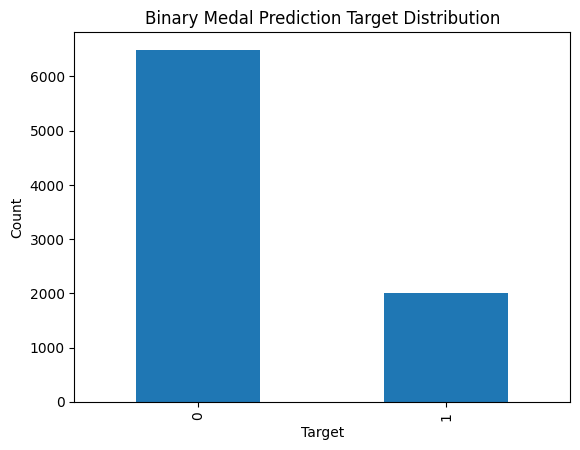

In [8]:
# Visualize the binary target distribution.
# This helps confirm class imbalance before training

import matplotlib.pyplot as plt

df_model["target"].value_counts().plot(kind="bar")
plt.title("Binary Medal Prediction Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()